# 04 - Treino LSTM (PyTorch)

LSTM bidirecional com pooling (attention, mean, last) e features estilométricas.

- **Dataset**: `data/processed/dataset_combined.csv`
- **Validações**: `dataset-exemplos.csv` e `subm1_labels_revealed.csv`
- **Método**: Optuna com 20 trials


In [1]:
import sys
import os
sys.path.append(os.path.abspath('..'))


In [2]:
import random
import time

import matplotlib.pyplot as plt
import numpy as np
import optuna
import pandas as pd
import torch
import torch.nn as nn
from sklearn.metrics import accuracy_score, auc, classification_report, confusion_matrix, roc_curve
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import label_binarize
from torch.utils.data import DataLoader

from src.data_processing import clean_text_sequences
from src.features import TextDataset, Vocabulary, load_glove_embeddings, texts_to_sequences
from src.hyperopt import create_study, study_results_dataframe, suggest_params
from src.models_pytorch.lstm import LSTMClassifier
from src.stylometric_features import StylometricFeaturesExtractor


In [3]:
# Configuração
DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
SEED = 42
N_TRIALS = 20
MAX_LEN = 150

random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
optuna.logging.set_verbosity(optuna.logging.WARNING)

print(f'Device: {DEVICE}')


Device: cuda


## 1. Carregamento de Dados

In [4]:
# Constantes
ROOT = os.path.abspath('..')
CLASSES = ['Anthropic', 'Google', 'Human', 'Meta', 'OpenAI']
LABEL_MAP = {label: i for i, label in enumerate(CLASSES)}
IDX_TO_LABEL = {v: k for k, v in LABEL_MAP.items()}
NUM_CLASSES = len(CLASSES)

TRAIN_PATH = os.path.join(ROOT, 'data', 'processed', 'dataset_combined.csv')
VAL1_PATH = os.path.join(ROOT, 'data', 'validation', 'dataset-exemplos.csv')
VAL2_PATH = os.path.join(ROOT, 'data', 'validation', 'subm1_labels_revealed.csv')

print(f'Classes: {LABEL_MAP}')


def load_data(path):
    df = pd.read_csv(path, sep=';')
    df = df[df['Label'].isin(CLASSES)].copy()
    df['label_id'] = df['Label'].map(LABEL_MAP)
    df['text_clean'] = df['Text'].apply(clean_text_sequences)
    return df


df_train = load_data(TRAIN_PATH)
df_val1 = load_data(VAL1_PATH)
df_val2 = load_data(VAL2_PATH)

print(f'Train: {len(df_train)} amostras')
print(f'  Labels: {df_train["Label"].value_counts().to_dict()}')
print(f'Val1 (exemplos): {len(df_val1)} amostras')
print(f'Val2 (subm1): {len(df_val2)} amostras')


Classes: {'Anthropic': 0, 'Google': 1, 'Human': 2, 'Meta': 3, 'OpenAI': 4}
Train: 2566 amostras
  Labels: {'Human': 567, 'Meta': 555, 'Google': 525, 'Anthropic': 488, 'OpenAI': 431}
Val1 (exemplos): 125 amostras
Val2 (subm1): 100 amostras


## 2. Funções de Treino

In [5]:
def train_epoch(model, loader, optimizer, criterion, device):
    model.train()
    total_loss, correct, total = 0.0, 0, 0
    for batch in loader:
        if len(batch) == 3:
            seqs, style_batch, labs = batch
            style_batch = style_batch.to(device)
        else:
            seqs, labs = batch
            style_batch = None
        seqs, labs = seqs.to(device), labs.to(device)
        optimizer.zero_grad()
        out = model(seqs, style_batch)
        loss = criterion(out, labs)
        loss.backward()
        torch.nn.utils.clip_grad_norm_(model.parameters(), 1.0)
        optimizer.step()
        total_loss += loss.item() * len(labs)
        correct += (out.argmax(dim=1) == labs).sum().item()
        total += len(labs)
    return total_loss / total, correct / total


def eval_epoch(model, loader, criterion, device):
    model.eval()
    total_loss, correct, total = 0.0, 0, 0
    with torch.no_grad():
        for batch in loader:
            if len(batch) == 3:
                seqs, style_batch, labs = batch
                style_batch = style_batch.to(device)
            else:
                seqs, labs = batch
                style_batch = None
            seqs, labs = seqs.to(device), labs.to(device)
            out = model(seqs, style_batch)
            loss = criterion(out, labs)
            total_loss += loss.item() * len(labs)
            correct += (out.argmax(dim=1) == labs).sum().item()
            total += len(labs)
    return total_loss / total, correct / total


def train_lstm(params, X_train_seq, y_train, X_val_seq, y_val, vocab, device, X_train_style=None, X_val_style=None):
    pretrained_embeddings = None
    glove_path = f"../data/embeddings/glove.6B.{params['embedding_dim']}d.txt"
    if os.path.exists(glove_path):
        pretrained_embeddings = load_glove_embeddings(
            glove_path, vocab, embedding_dim=params['embedding_dim']
        )
    else:
        print(f"Warning: {glove_path} not found, training embeddings from scratch")

    model = LSTMClassifier(
        vocab_size=len(vocab),
        embedding_dim=params['embedding_dim'],
        hidden_dim=params['hidden_dim'],
        output_dim=NUM_CLASSES,
        n_layers=params['n_layers'],
        dropout=params['dropout'],
        pooling=params['pooling'],
        pretrained_embeddings=pretrained_embeddings,
        n_style_features=X_train_style.shape[1] if X_train_style is not None else 0,
    ).to(device)

    criterion = nn.CrossEntropyLoss()
    optimizer = torch.optim.Adam(model.parameters(), lr=params['lr'])

    train_ds = TextDataset(X_train_seq, y_train, X_train_style)
    val_ds = TextDataset(X_val_seq, y_val, X_val_style)
    train_dl = DataLoader(train_ds, batch_size=params['batch_size'], shuffle=True)
    val_dl = DataLoader(val_ds, batch_size=params['batch_size'])

    best_val_acc = -1.0
    best_state = None
    patience_counter = 0
    history = {'train_loss': [], 'val_loss': [], 'train_acc': [], 'val_acc': []}

    t0 = time.time()
    for epoch in range(params['epochs']):
        tr_loss, tr_acc = train_epoch(model, train_dl, optimizer, criterion, device)
        vl_loss, vl_acc = eval_epoch(model, val_dl, criterion, device)

        history['train_loss'].append(tr_loss)
        history['val_loss'].append(vl_loss)
        history['train_acc'].append(tr_acc)
        history['val_acc'].append(vl_acc)

        if vl_acc > best_val_acc:
            best_val_acc = vl_acc
            best_state = {k: v.detach().cpu().clone() for k, v in model.state_dict().items()}
            patience_counter = 0
        else:
            patience_counter += 1
            if patience_counter >= 10:
                break

    if best_state is not None:
        model.load_state_dict(best_state)

    train_time = time.time() - t0
    return model, best_val_acc, max(history['train_acc']), history, train_time


def evaluate_external_lstm(model, X_seq, y_labels, batch_size, device, X_style=None):
    ds = TextDataset(X_seq, y_labels, X_style)
    dl = DataLoader(ds, batch_size=batch_size)
    model.eval()
    correct, total = 0, 0
    with torch.no_grad():
        for batch in dl:
            if len(batch) == 3:
                seqs, style_batch, labs = batch
                style_batch = style_batch.to(device)
            else:
                seqs, labs = batch
                style_batch = None
            seqs, labs = seqs.to(device), labs.to(device)
            out = model(seqs, style_batch)
            correct += (out.argmax(dim=1) == labs).sum().item()
            total += len(labs)
    return correct / total


def get_predictions_lstm(model, X_seq, y_labels, batch_size, device, X_style=None):
    ds = TextDataset(X_seq, y_labels, X_style)
    dl = DataLoader(ds, batch_size=batch_size)
    model.eval()
    all_probs, all_labels = [], []
    with torch.no_grad():
        for batch in dl:
            if len(batch) == 3:
                seqs, style_batch, labs = batch
                style_batch = style_batch.to(device)
            else:
                seqs, labs = batch
                style_batch = None
            out = model(seqs.to(device), style_batch)
            probs = torch.softmax(out, dim=1).cpu().numpy()
            all_probs.append(probs)
            all_labels.append(labs.numpy())
    return np.vstack(all_probs), np.concatenate(all_labels)


def full_evaluation_lstm(model, X_seq, y_labels, name, batch_size, device, X_style=None):
    probs, labels = get_predictions_lstm(model, X_seq, y_labels, batch_size, device, X_style)
    preds = np.argmax(probs, axis=1)
    acc = accuracy_score(labels, preds)

    print(f'\n=== {name} ===')
    print(f'Accuracy: {acc:.4f}')
    print()
    print(classification_report(labels, preds, target_names=CLASSES, zero_division=0))

    fig, ax = plt.subplots(figsize=(8, 6))
    cm = confusion_matrix(labels, preds)
    im = ax.imshow(cm, interpolation='nearest', cmap='Blues')
    ax.figure.colorbar(im, ax=ax)
    ax.set(
        xticks=np.arange(NUM_CLASSES),
        yticks=np.arange(NUM_CLASSES),
        xticklabels=CLASSES,
        yticklabels=CLASSES,
        ylabel='Real',
        xlabel='Previsto',
        title=f'Matriz de Confusão — {name}',
    )
    plt.setp(ax.get_xticklabels(), rotation=45, ha='right')

    for i in range(NUM_CLASSES):
        for j in range(NUM_CLASSES):
            ax.text(
                j, i, format(cm[i, j], 'd'), ha='center', va='center',
                color='white' if cm[i, j] > cm.max() / 2 else 'black'
            )

    plt.tight_layout()
    plt.show()
    return probs, labels


## 3. Espaço de Busca e Optuna

In [6]:
style_extractor = StylometricFeaturesExtractor()
X_train_style_all = style_extractor.fit_transform(list(df_train['Text']))
X_val1_style = style_extractor.transform(list(df_val1['Text']))
X_val2_style = style_extractor.transform(list(df_val2['Text']))

style_mean = X_train_style_all.mean(axis=0)
style_std = X_train_style_all.std(axis=0) + 1e-8
X_train_style_all = (X_train_style_all - style_mean) / style_std
X_val1_style = (X_val1_style - style_mean) / style_std
X_val2_style = (X_val2_style - style_mean) / style_std
print(f'Style features shape: {X_train_style_all.shape}')

vocab = Vocabulary(max_words=5000)
vocab.fit(list(df_train['text_clean']))
print(f'Vocabulário: {len(vocab)} palavras')

X_train_seq_all = texts_to_sequences(list(df_train['text_clean']), vocab, max_len=MAX_LEN)
y_all = df_train['label_id'].values.astype(np.int64)

train_idx, val_idx = train_test_split(
    np.arange(len(X_train_seq_all)),
    test_size=0.2,
    random_state=SEED,
    stratify=y_all,
)

X_tr = X_train_seq_all[train_idx]
X_te = X_train_seq_all[val_idx]
y_tr = y_all[train_idx]
y_te = y_all[val_idx]
X_train_style = X_train_style_all[train_idx]
X_val_style = X_train_style_all[val_idx]

X_val1_seq = texts_to_sequences(list(df_val1['text_clean']), vocab, max_len=MAX_LEN)
y_val1 = df_val1['label_id'].values.astype(np.int64)
X_val2_seq = texts_to_sequences(list(df_val2['text_clean']), vocab, max_len=MAX_LEN)
y_val2 = df_val2['label_id'].values.astype(np.int64)

search_space = {
    'hidden_dim': [64, 128, 256],
    'n_layers': [1, 2],
    'dropout': [0.3, 0.5],
    'pooling': ['attention', 'mean', 'last'],
    'embedding_dim': [50, 100],
    'lr': [0.001, 0.005],
    'batch_size': [32, 64],
    'epochs': [30, 50],
}

print('Opções por parâmetro:')
for k, v in search_space.items():
    print(f'  {k}: {len(v)} opções')


Style features shape: (2566, 18)
Vocabulário: 5002 palavras
Opções por parâmetro:
  hidden_dim: 3 opções
  n_layers: 2 opções
  dropout: 2 opções
  pooling: 3 opções
  embedding_dim: 2 opções
  lr: 2 opções
  batch_size: 2 opções
  epochs: 2 opções


In [7]:
def objective(trial):
    params = suggest_params(trial, search_space)

    print(
        f"[Trial {trial.number}] h={params['hidden_dim']} layers={params['n_layers']} "
        f"pool={params['pooling']} emb={params['embedding_dim']} lr={params['lr']} "
        f"bs={params['batch_size']} epochs={params['epochs']}"
    )

    model, val_acc, train_acc, history, train_time = train_lstm(
        params,
        X_tr,
        y_tr,
        X_te,
        y_te,
        vocab,
        DEVICE,
        X_train_style=X_train_style,
        X_val_style=X_val_style,
    )

    val1_acc = evaluate_external_lstm(model, X_val1_seq, y_val1, params['batch_size'], DEVICE, X_style=X_val1_style)
    val2_acc = evaluate_external_lstm(model, X_val2_seq, y_val2, params['batch_size'], DEVICE, X_style=X_val2_style)

    trial.set_user_attr('internal_val', val_acc)
    trial.set_user_attr('train_acc', train_acc)
    trial.set_user_attr('val1_acc', val1_acc)
    trial.set_user_attr('val2_acc', val2_acc)
    trial.set_user_attr('train_time', train_time)

    print(f"  -> internal={val_acc:.4f} | val1={val1_acc:.4f} | val2={val2_acc:.4f} ({train_time:.1f}s)")
    return val_acc


study = create_study(direction='maximize', study_name='lstm_pytorch_optuna', seed=SEED)
study.optimize(objective, n_trials=N_TRIALS)

results_df = study_results_dataframe(study)
results_df = results_df[results_df['state'] == 'COMPLETE'].copy()
results_df = results_df.sort_values('internal_val', ascending=False).reset_index(drop=True)

best_trial = study.best_trial
best_params = best_trial.params.copy()
best_internal_val = best_trial.value

print('=== Top 5 Modelos (por internal_val) ===')
print(results_df.head(5)[[
    'trial', 'hidden_dim', 'n_layers', 'pooling', 'dropout', 'embedding_dim',
    'lr', 'batch_size', 'epochs', 'internal_val', 'val1_acc', 'val2_acc'
]].to_string(index=False))


[Trial 0] h=128 layers=1 pool=attention emb=100 lr=0.001 bs=64 epochs=50
GloVe: 4969/5002 palavras encontradas (99.3%)
  -> internal=0.8872 | val1=0.4560 | val2=0.4500 (44.5s)
[Trial 1] h=256 layers=2 pool=attention emb=50 lr=0.001 bs=64 epochs=30
  -> internal=0.7899 | val1=0.4720 | val2=0.4500 (121.9s)
[Trial 2] h=256 layers=1 pool=attention emb=100 lr=0.001 bs=32 epochs=30
GloVe: 4969/5002 palavras encontradas (99.3%)
  -> internal=0.8755 | val1=0.4400 | val2=0.5400 (64.0s)
[Trial 3] h=128 layers=1 pool=mean emb=100 lr=0.005 bs=64 epochs=30
GloVe: 4969/5002 palavras encontradas (99.3%)
  -> internal=0.9125 | val1=0.4560 | val2=0.4300 (72.0s)
[Trial 4] h=128 layers=2 pool=mean emb=50 lr=0.005 bs=32 epochs=30
  -> internal=0.8755 | val1=0.4960 | val2=0.4800 (586.2s)
[Trial 5] h=256 layers=2 pool=attention emb=100 lr=0.005 bs=32 epochs=50
GloVe: 4969/5002 palavras encontradas (99.3%)
  -> internal=0.9027 | val1=0.4640 | val2=0.5000 (147.0s)
[Trial 6] h=256 layers=2 pool=attention emb=5

## 4. Resultados

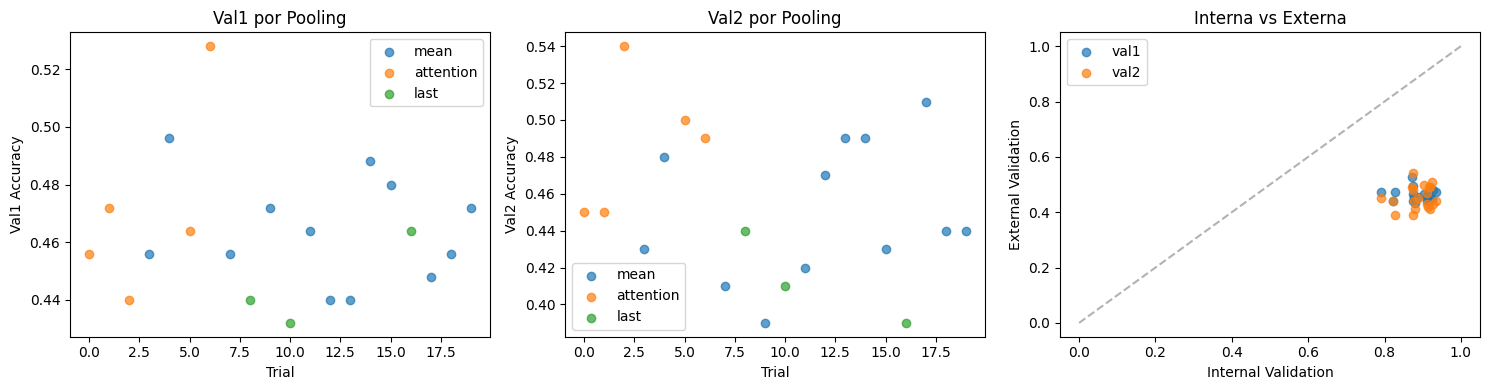

In [8]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

for pool in results_df['pooling'].unique():
    mask = results_df['pooling'] == pool
    axes[0].scatter(results_df[mask]['trial'], results_df[mask]['val1_acc'], label=pool, alpha=0.7)
axes[0].set_xlabel('Trial')
axes[0].set_ylabel('Val1 Accuracy')
axes[0].set_title('Val1 por Pooling')
axes[0].legend()

for pool in results_df['pooling'].unique():
    mask = results_df['pooling'] == pool
    axes[1].scatter(results_df[mask]['trial'], results_df[mask]['val2_acc'], label=pool, alpha=0.7)
axes[1].set_xlabel('Trial')
axes[1].set_ylabel('Val2 Accuracy')
axes[1].set_title('Val2 por Pooling')
axes[1].legend()

axes[2].scatter(results_df['internal_val'], results_df['val1_acc'], label='val1', alpha=0.7)
axes[2].scatter(results_df['internal_val'], results_df['val2_acc'], label='val2', alpha=0.7)
axes[2].plot([0, 1], [0, 1], 'k--', alpha=0.3)
axes[2].set_xlabel('Internal Validation')
axes[2].set_ylabel('External Validation')
axes[2].set_title('Interna vs Externa')
axes[2].legend()

plt.tight_layout()
plt.show()


## 5. Avaliação Detalhada do Melhor Modelo

In [9]:
print('=== Melhor Modelo LSTM ===')
for key, value in best_params.items():
    print(f'{key}: {value}')
print(f'Best Internal Validation Accuracy: {best_internal_val:.4f}')

best_model, _, _, best_history, _ = train_lstm(
    best_params,
    X_tr,
    y_tr,
    X_te,
    y_te,
    vocab,
    DEVICE,
    X_train_style=X_train_style,
    X_val_style=X_val_style,
)


=== Melhor Modelo LSTM ===
hidden_dim: 64
n_layers: 1
dropout: 0.3
pooling: mean
embedding_dim: 100
lr: 0.005
batch_size: 64
epochs: 30
Best Internal Validation Accuracy: 0.9339
GloVe: 4969/5002 palavras encontradas (99.3%)



=== Val1 (exemplos) ===
Accuracy: 0.4080

              precision    recall  f1-score   support

   Anthropic       0.25      0.04      0.07        23
      Google       0.18      0.25      0.21        16
       Human       0.51      0.87      0.64        52
        Meta       0.00      0.00      0.00        17
      OpenAI       0.10      0.06      0.07        17

    accuracy                           0.41       125
   macro avg       0.21      0.24      0.20       125
weighted avg       0.30      0.41      0.32       125



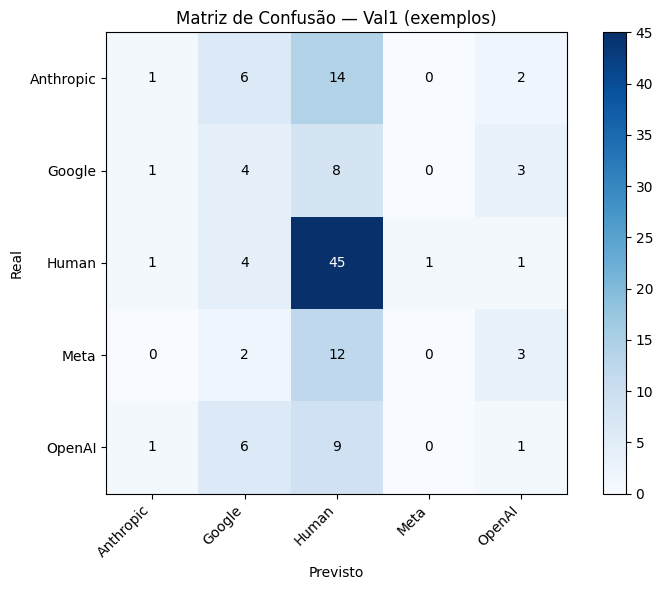


=== Val2 (subm1) ===
Accuracy: 0.4000

              precision    recall  f1-score   support

   Anthropic       0.20      0.12      0.15        17
      Google       0.33      0.12      0.17        17
       Human       0.40      0.91      0.56        34
        Meta       1.00      0.22      0.36        18
      OpenAI       0.33      0.07      0.12        14

    accuracy                           0.40       100
   macro avg       0.45      0.29      0.27       100
weighted avg       0.45      0.40      0.33       100



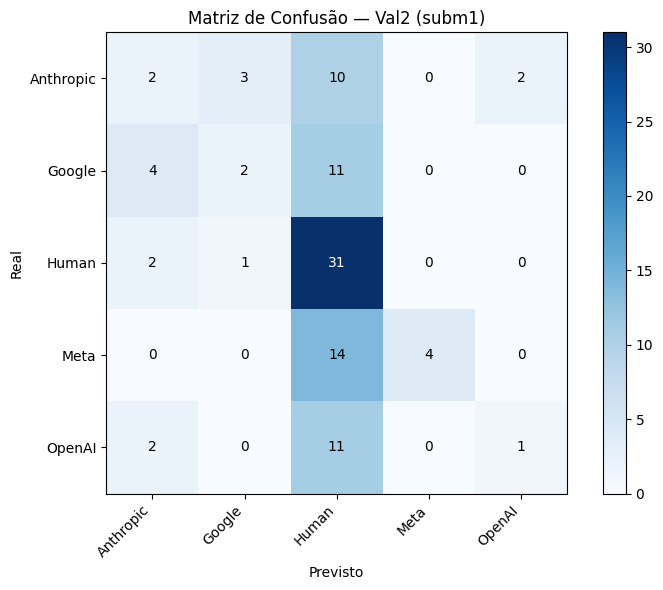

In [10]:
probs_val1, labels_val1 = full_evaluation_lstm(
    best_model, X_val1_seq, y_val1, 'Val1 (exemplos)',
    best_params['batch_size'], DEVICE, X_style=X_val1_style,
)
probs_val2, labels_val2 = full_evaluation_lstm(
    best_model, X_val2_seq, y_val2, 'Val2 (subm1)',
    best_params['batch_size'], DEVICE, X_style=X_val2_style,
)


## 6. Curva ROC (Macro Average)

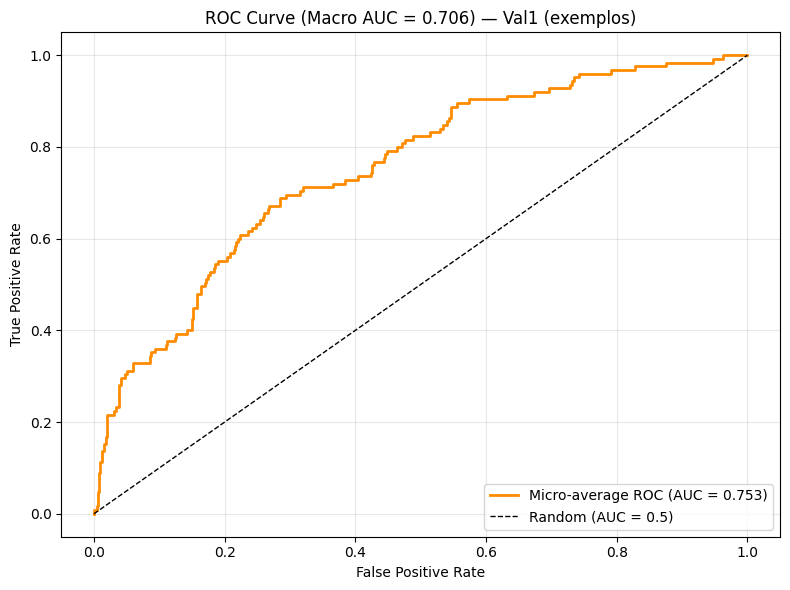

Val1 (exemplos): Micro AUC = 0.7527, Macro AUC = 0.7063


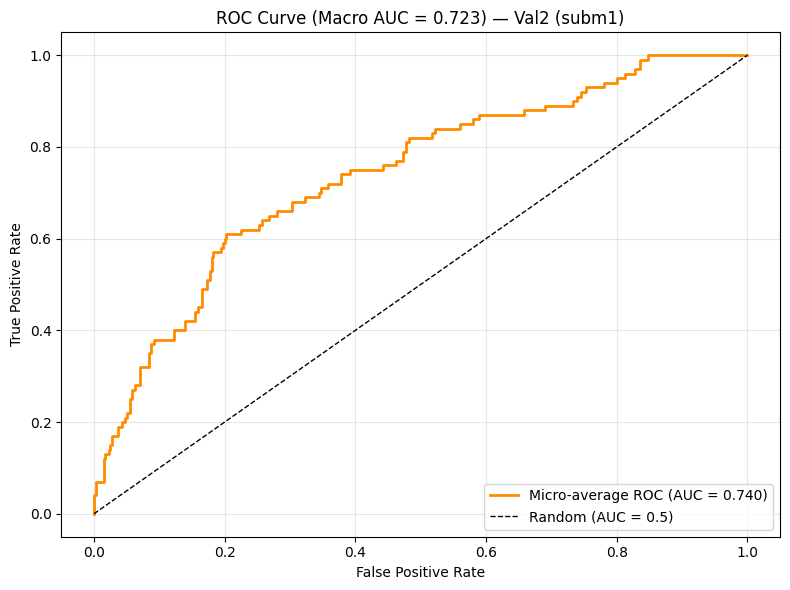

Val2 (subm1): Micro AUC = 0.7404, Macro AUC = 0.7226


In [11]:
def plot_roc_macro(probs, labels, name):
    labels_bin = label_binarize(labels, classes=range(NUM_CLASSES))

    fpr, tpr, _ = roc_curve(labels_bin.ravel(), probs.ravel())
    roc_auc = auc(fpr, tpr)

    aucs = []
    for i in range(NUM_CLASSES):
        fpr_i, tpr_i, _ = roc_curve(labels_bin[:, i], probs[:, i])
        aucs.append(auc(fpr_i, tpr_i))
    macro_auc = np.mean(aucs)

    plt.figure(figsize=(8, 6))
    plt.plot(fpr, tpr, color='darkorange', lw=2, label=f'Micro-average ROC (AUC = {roc_auc:.3f})')
    plt.plot([0, 1], [0, 1], 'k--', lw=1, label='Random (AUC = 0.5)')
    plt.xlabel('False Positive Rate')
    plt.ylabel('True Positive Rate')
    plt.title(f'ROC Curve (Macro AUC = {macro_auc:.3f}) — {name}')
    plt.legend(loc='lower right')
    plt.grid(alpha=0.3)
    plt.tight_layout()
    plt.show()

    print(f'{name}: Micro AUC = {roc_auc:.4f}, Macro AUC = {macro_auc:.4f}')
    return macro_auc


macro_auc_val1 = plot_roc_macro(probs_val1, labels_val1, 'Val1 (exemplos)')
macro_auc_val2 = plot_roc_macro(probs_val2, labels_val2, 'Val2 (subm1)')


## 7. Conclusões

In [12]:
print('=' * 60)
print('CONCLUSÕES — LSTM')
print('=' * 60)
print()

print('Média por pooling:')
for pool in results_df['pooling'].unique():
    mask = results_df['pooling'] == pool
    mean_v1 = results_df[mask]['val1_acc'].mean()
    mean_v2 = results_df[mask]['val2_acc'].mean()
    print(f'  {pool:10s}: val1={mean_v1:.4f} | val2={mean_v2:.4f}')

print()
print('Melhor configuração:')
for key, value in best_params.items():
    print(f'  {key}: {value}')
print(f'Best Internal Validation Accuracy: {best_internal_val:.4f}')
print(f'Val1 AUC (macro): {macro_auc_val1:.4f}')
print(f'Val2 Accuracy: {results_df.loc[results_df["internal_val"].idxmax(), "val2_acc"]:.4f}')
print(f'Val2 AUC (macro): {macro_auc_val2:.4f}')

results_path = os.path.join(ROOT, 'data', 'processed', 'lstm_results.csv')
results_df.to_csv(results_path, index=False)
print(f'Resultados guardados em {results_path}')


CONCLUSÕES — LSTM

Média por pooling:
  mean      : val1=0.4640 | val2=0.4500
  attention : val1=0.4720 | val2=0.4860
  last      : val1=0.4453 | val2=0.4133

Melhor configuração:
  hidden_dim: 64
  n_layers: 1
  dropout: 0.3
  pooling: mean
  embedding_dim: 100
  lr: 0.005
  batch_size: 64
  epochs: 30
Best Internal Validation Accuracy: 0.9339
Val1 AUC (macro): 0.7063
Val2 Accuracy: 0.4400
Val2 AUC (macro): 0.7226
Resultados guardados em /home/joaocunha50/studys/university/MEI/1_ano/AP/Projeto-AP/data/processed/lstm_results.csv
